# Malaria Geospatial Analysis and Regional Epidemic Modelling

This notebook follows the assignment requirements:

1. Select at least three comparable or contrasting regions and define the spatial scale.
2. Perform mandatory geospatial analysis before modelling.
3. Fit two models to the same regional data:
   - Model A: mechanistic SIR model
   - Model B: statistical time-series ARIMA model

The malaria data were extracted from the supplied PDF files into CSV format.

## 0. Setup

Run the install cell once if these packages are not already available in your notebook environment.

In [1]:
# Uncomment and run this cell if packages are missing.
# %pip install pandas numpy matplotlib plotly scipy statsmodels scikit-learn
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
ANALYSIS_READY_DIR = DATA_DIR / "analysis_ready"
RAW_DIR = DATA_DIR / "raw"

STATE_YEAR_CSV = ANALYSIS_READY_DIR / "state_year_malaria_clean.csv"
GEOJSON_PATH = RAW_DIR / "india_states.geojson"

missing_paths = [path for path in [STATE_YEAR_CSV, GEOJSON_PATH] if not path.exists()]
if missing_paths:
    missing = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(f"Required input file(s) missing:\n{missing}")

SELECTED_REGIONS = ["Odisha", "Mizoram", "Tripura"]
SPATIAL_SCALE = "state-level"

## 1. Select Regions and Spatial Scale

**Spatial scale:** state-level analysis within India.

**Selected regions:** Odisha, Mizoram, and Tripura.

**Justification:**

- These states are comparable because they all show substantial malaria burden in the provided dataset.
- They are contrasting because they differ sharply in population size, geography, and epidemic intensity.
- Odisha has high raw case counts and a large population.
- Mizoram has a much smaller population but high malaria intensity, making per-capita rates especially important.
- Tripura provides another northeastern comparison with strong malaria burden but a different trend profile.

This makes the three-region comparison useful for showing why raw case counts and population-adjusted rates can lead to different interpretations.

In [3]:
state_year = pd.read_csv(STATE_YEAR_CSV)
numeric_cols = [
    "year",
    "total_cases",
    "total_deaths",
    "district_count",
    "population_2011",
    "cases_per_100k",
    "deaths_per_100k",
]
for col in numeric_cols:
    state_year[col] = pd.to_numeric(state_year[col], errors="coerce")

selected = state_year[state_year["state"].isin(SELECTED_REGIONS)].copy()

print("Selected regions:", SELECTED_REGIONS)
print("Spatial scale:", SPATIAL_SCALE)
display(selected.head())

Selected regions: ['Odisha', 'Mizoram', 'Tripura']
Spatial scale: state-level


,year,state,total_cases,total_deaths,district_count,population_2011,cases_per_100k,deaths_per_100k,selected_region
23,2000,Mizoram,9059,33,4,1097206,825.642587,3.007639,yes
25,2000,Odisha,509497,467,30,41974218,1213.833215,1.112588,yes
31,2000,Tripura,12245,6,4,3673917,333.295499,0.163313,yes
58,2001,Mizoram,10929,43,5,1097206,996.075486,3.919045,yes
60,2001,Odisha,454541,305,30,41974218,1082.905225,0.726637,yes


## 2. Mandatory Geospatial Data Analysis

This section comes before modelling, as required.

It includes:

- Choropleth map of cumulative cases
- Choropleth map of per-capita case rates
- Temporal snapshots for early, peak, and late epidemic periods
- Interpretation of spatial heterogeneity and implications for modelling

The downloaded GeoJSON is district-level. For state-level choropleths, each district polygon is colored using its state's value. This preserves real geography while keeping the modelling scale at state level.

In [4]:
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    india_geojson = json.load(f)

STATE_NAME_FIX = {
    "Andaman and Nicobar Islands": "Andaman And Nicobar Islands",
    "Dadra and Nagar Haveli and Daman and Diu": "The Dadra And Nagar Haveli And Daman And Diu",
    "Jammu and Kashmir": "Jammu And Kashmir",
}

geo_rows = []
for index, feature in enumerate(india_geojson["features"]):
    props = feature["properties"]
    map_state = props["st_nm"]
    data_state = STATE_NAME_FIX.get(map_state, map_state)
    feature_id = str(props.get("dt_code") or f"feature_{index}")
    props["_feature_id"] = feature_id
    geo_rows.append({
        "feature_id": feature_id,
        "map_state": map_state,
        "state": data_state,
        "map_district": props.get("district", map_state),
    })

geo_index = pd.DataFrame(geo_rows)
geo_index.head()

,feature_id,map_state,state,map_district
0,261,Mizoram,Mizoram,Aizawl
1,262,Mizoram,Mizoram,Champhai
2,263,Mizoram,Mizoram,Kolasib
3,264,Mizoram,Mizoram,Lawngtlai
4,265,Mizoram,Mizoram,Lunglei


In [5]:
cumulative = (
    state_year
    .groupby("state", as_index=False)
    .agg(
        cumulative_cases=("total_cases", "sum"),
        population_2011=("population_2011", "first"),
    )
)
cumulative["cumulative_cases_per_100k"] = (
    cumulative["cumulative_cases"] / cumulative["population_2011"] * 100_000
)

map_cumulative = geo_index.merge(cumulative, on="state", how="left")

def plot_choropleth(map_df, value_col, title, color_scale="YlOrRd"):
    fig = px.choropleth(
        map_df,
        geojson=india_geojson,
        locations="feature_id",
        featureidkey="properties._feature_id",
        color=value_col,
        hover_name="map_district",
        hover_data={
            "map_state": True,
            value_col: ":,.2f",
            "feature_id": False,
        },
        color_continuous_scale=color_scale,
        title=title,
    )
    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
    fig.show(renderer="browser")

plot_choropleth(
    map_cumulative,
    "cumulative_cases",
    "Cumulative Malaria Cases by State, 2000-2024",
)


In [6]:
plot_choropleth(
    map_cumulative,
    "cumulative_cases_per_100k",
    "Cumulative Malaria Case Rate per 100,000 Population, 2000-2024",
    color_scale="Viridis",
)

In [7]:
national_by_year = (
    state_year
    .groupby("year", as_index=False)
    .agg(total_cases=("total_cases", "sum"))
    .sort_values("year")
)

early_year = int(national_by_year["year"].min())
peak_year = int(national_by_year.loc[national_by_year["total_cases"].idxmax(), "year"])
late_year = int(national_by_year["year"].max())

print("Temporal snapshots:")
print("Early year:", early_year)
print("Peak year by national total cases:", peak_year)
print("Late year:", late_year)

snapshot_years = [early_year, peak_year, late_year]
snapshot_data = state_year[state_year["year"].isin(snapshot_years)].copy()

Temporal snapshots:
Early year: 2000
Peak year by national total cases: 2001
Late year: 2024


In [8]:
for year in snapshot_years:
    year_metrics = state_year[state_year["year"] == year][
        ["state", "total_cases", "cases_per_100k"]
    ]
    map_year = geo_index.merge(year_metrics, on="state", how="left")
    plot_choropleth(
        map_year,
        "cases_per_100k",
        f"Temporal Snapshot: Malaria Case Rate per 100,000 in {year}",
        color_scale="Plasma",
    )

,state,cumulative_cases,population_2011,cumulative_cases_per_100k
24,Mizoram,259793,1097206,23677.686779
26,Odisha,7242716,41974218,17255.154104
34,Tripura,377059,3673917,10263.133326


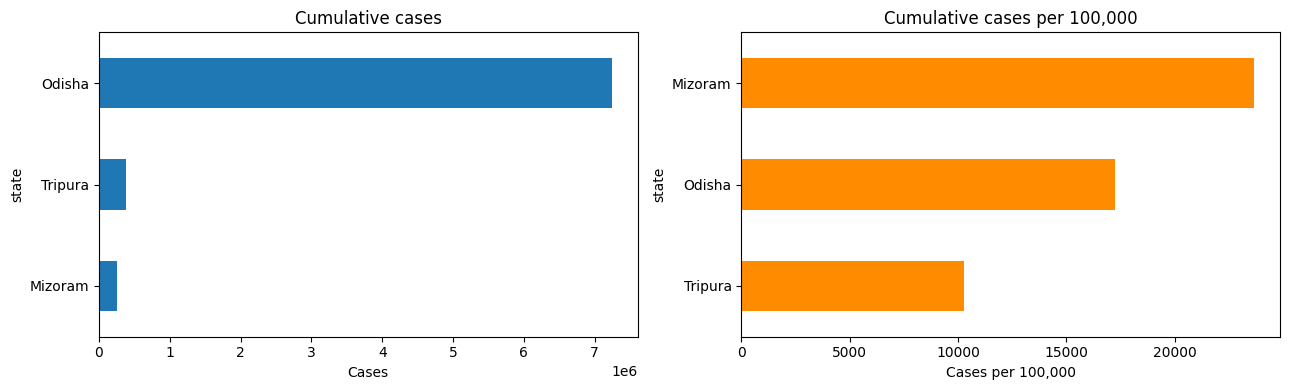

In [9]:
comparison = (
    cumulative[cumulative["state"].isin(SELECTED_REGIONS)]
    .sort_values("cumulative_cases_per_100k", ascending=False)
)

display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comparison.sort_values("cumulative_cases").plot(
    x="state", y="cumulative_cases", kind="barh", ax=axes[0], legend=False
)
axes[0].set_title("Cumulative cases")
axes[0].set_xlabel("Cases")

comparison.sort_values("cumulative_cases_per_100k").plot(
    x="state", y="cumulative_cases_per_100k", kind="barh", ax=axes[1], legend=False, color="darkorange"
)
axes[1].set_title("Cumulative cases per 100,000")
axes[1].set_xlabel("Cases per 100,000")

plt.tight_layout()
plt.show()

### Geospatial Interpretation

**Do all regions show similar epidemic intensity?**

No. Odisha, Mizoram, and Tripura all show meaningful malaria burden, but the intensity differs strongly. Odisha is expected to dominate raw cumulative counts because it has a much larger population. Mizoram and Tripura can appear more intense after adjusting for population.

**Are raw counts misleading compared to per-capita rates?**

Yes. Raw counts emphasize larger states, while per-capita rates reveal where the disease burden is intense relative to population size. This is especially important for smaller states like Mizoram and Tripura.

**What spatial patterns might affect model behavior?**

Spatial heterogeneity means one shared model would be inappropriate. High-burden regions can have different transmission patterns, surveillance intensity, population denominators, ecological conditions, and health-system response. Therefore, the mechanistic and ML models are fit separately for each selected region.

## 3. Model A: Mechanistic Model

### Model Choice

We use a simple SIR model because the available malaria data contain annual case counts but not exposed, recovered, relapse, vector abundance, immunity, or mosquito infection data.

Malaria is vector-borne, so a full biological model would ideally use a Ross-Macdonald or vector-host framework. Here, SIR is used as a simplified mechanistic approximation to compare region-specific transmission behavior.

### Compartments

- **S(t):** susceptible population
- **I(t):** infected population
- **R(t):** removed/recovered population
- **C(t):** cumulative infections generated by the model

### Parameters

- **beta:** transmission rate
- **gamma:** recovery/removal rate
- **R0 = beta / gamma:** basic reproduction number proxy

Parameters are estimated separately for each region by minimizing the squared error between observed annual malaria cases and model-generated annual infections.

In [10]:
def sir_with_cumulative(t, y, beta, gamma, population):
    S, I, R, C = y
    new_infections = beta * S * I / population
    dS = -new_infections
    dI = new_infections - gamma * I
    dR = gamma * I
    dC = new_infections
    return [dS, dI, dR, dC]

def simulate_sir_annual(beta, gamma, population, initial_infected, n_years):
    initial_infected = max(1.0, min(initial_infected, population * 0.1))
    y0 = [population - initial_infected, initial_infected, 0.0, 0.0]
    t_eval = np.arange(0, n_years + 1)
    sol = solve_ivp(
        sir_with_cumulative,
        [0, n_years],
        y0,
        t_eval=t_eval,
        args=(beta, gamma, population),
        method="RK45",
    )
    cumulative = sol.y[3]
    annual_cases = np.diff(cumulative)
    return np.maximum(annual_cases, 0)

def fit_sir_for_region(region_df):
    region_df = region_df.sort_values("year")
    observed = region_df["total_cases"].to_numpy(dtype=float)
    population = float(region_df["population_2011"].iloc[0])
    n_years = len(observed)

    def objective(params):
        beta, gamma, initial_infected = params
        pred = simulate_sir_annual(beta, gamma, population, initial_infected, n_years)
        return np.mean((np.log1p(observed) - np.log1p(pred)) ** 2)

    initial_guess = [0.8, 0.5, max(1.0, observed[0])]
    bounds = [(1e-4, 5.0), (1e-4, 5.0), (1.0, max(10.0, population * 0.01))]
    result = minimize(objective, initial_guess, bounds=bounds, method="L-BFGS-B")

    beta, gamma, initial_infected = result.x
    fitted = simulate_sir_annual(beta, gamma, population, initial_infected, n_years)
    return {
        "beta": beta,
        "gamma": gamma,
        "R0_proxy": beta / gamma,
        "initial_infected": initial_infected,
        "sir_mae": mean_absolute_error(observed, fitted),
        "sir_rmse": np.sqrt(mean_squared_error(observed, fitted)),
        "fitted": fitted,
        "success": result.success,
    }

sir_results = {}
sir_summary_rows = []

for region in SELECTED_REGIONS:
    region_df = selected[selected["state"] == region].sort_values("year")
    fit = fit_sir_for_region(region_df)
    sir_results[region] = fit
    sir_summary_rows.append({
        "region": region,
        "beta": fit["beta"],
        "gamma": fit["gamma"],
        "R0_proxy": fit["R0_proxy"],
        "initial_infected": fit["initial_infected"],
        "MAE": fit["sir_mae"],
        "RMSE": fit["sir_rmse"],
        "optimizer_success": fit["success"],
    })

sir_summary = pd.DataFrame(sir_summary_rows)
display(sir_summary)

,region,beta,gamma,R0_proxy,initial_infected,MAE,RMSE,optimizer_success
0,Odisha,1.474578,1.387291,1.062919,419742.175772,112383.633050,150849.288966,True
1,Mizoram,0.722547,0.630272,1.146405,9058.999996,3570.779608,5457.878513,True
2,Tripura,1.518141,1.478052,1.027123,12245.000068,5622.521232,6927.684775,True


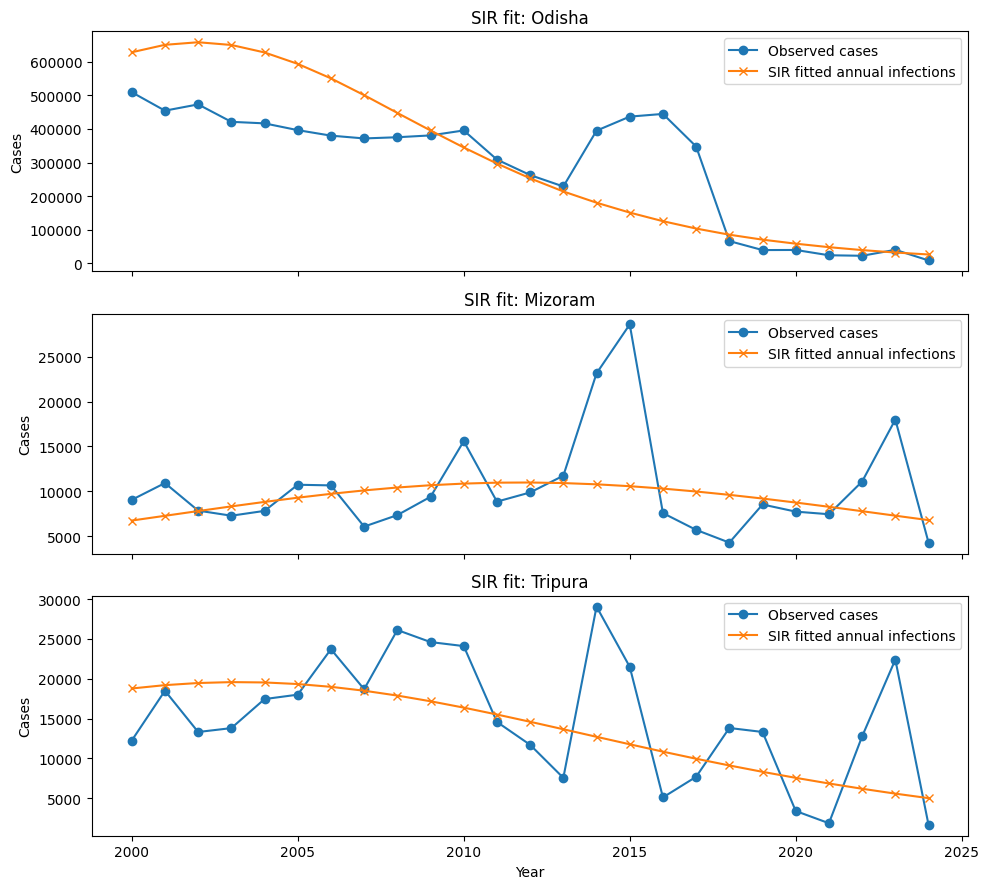

In [11]:
fig, axes = plt.subplots(len(SELECTED_REGIONS), 1, figsize=(10, 9), sharex=True)

for ax, region in zip(axes, SELECTED_REGIONS):
    region_df = selected[selected["state"] == region].sort_values("year")
    ax.plot(region_df["year"], region_df["total_cases"], marker="o", label="Observed cases")
    ax.plot(region_df["year"], sir_results[region]["fitted"], marker="x", label="SIR fitted annual infections")
    ax.set_title(f"SIR fit: {region}")
    ax.set_ylabel("Cases")
    ax.legend()

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

## 4. Model B: Time-Series ARIMA Model

We use ARIMA as the statistical time-series model. ARIMA treats each regional epidemic curve as a forecasting problem.

### What biological assumptions are not included?

ARIMA does not explicitly include:

- susceptible or recovered compartments
- mosquito/vector dynamics
- transmission mechanisms
- immunity or relapse
- rainfall, temperature, or intervention effects

It only learns statistical structure from past case counts. This makes it useful for forecasting baselines, but less biologically interpretable than mechanistic models.

In [12]:
def fit_arima_for_region(region_df, forecast_steps=4):
    region_df = region_df.sort_values("year")
    y = region_df["total_cases"].astype(float).to_numpy()
    years = region_df["year"].to_numpy()

    train_y = y[:-forecast_steps]
    test_y = y[-forecast_steps:]
    test_years = years[-forecast_steps:]

    candidate_orders = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 0), (1, 0, 0)]
    best_model = None
    best_order = None
    best_aic = np.inf

    for order in candidate_orders:
        try:
            model = ARIMA(train_y, order=order).fit()
            if model.aic < best_aic:
                best_model = model
                best_order = order
                best_aic = model.aic
        except Exception:
            continue

    if best_model is None:
        forecast = np.repeat(train_y[-1], forecast_steps)
        best_order = "naive_fallback"
        best_aic = np.nan
    else:
        forecast = np.asarray(best_model.forecast(steps=forecast_steps))
        forecast = np.maximum(forecast, 0)

    return {
        "order": best_order,
        "aic": best_aic,
        "test_years": test_years,
        "test_y": test_y,
        "forecast": forecast,
        "mae": mean_absolute_error(test_y, forecast),
        "rmse": np.sqrt(mean_squared_error(test_y, forecast)),
    }

arima_results = {}
arima_summary_rows = []

for region in SELECTED_REGIONS:
    region_df = selected[selected["state"] == region].sort_values("year")
    fit = fit_arima_for_region(region_df)
    arima_results[region] = fit
    arima_summary_rows.append({
        "region": region,
        "ARIMA_order": fit["order"],
        "AIC": fit["aic"],
        "MAE": fit["mae"],
        "RMSE": fit["rmse"],
    })

arima_summary = pd.DataFrame(arima_summary_rows)
display(arima_summary)

,region,ARIMA_order,AIC,MAE,RMSE
0,Odisha,"(1, 1, 0)",513.651695,16161.554771,19488.027262
1,Mizoram,"(1, 1, 1)",407.994752,4254.221287,5191.105169
2,Tripura,"(2, 1, 0)",417.126740,6605.252695,8098.672296


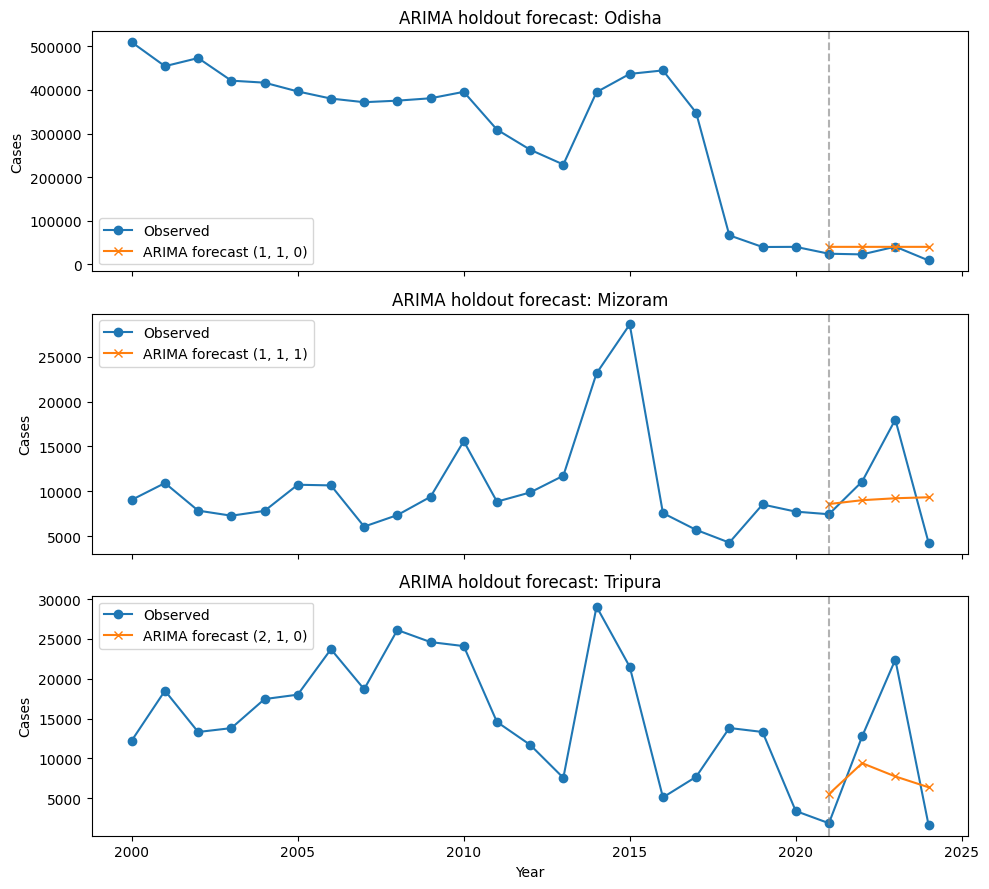

In [13]:
fig, axes = plt.subplots(len(SELECTED_REGIONS), 1, figsize=(10, 9), sharex=True)

for ax, region in zip(axes, SELECTED_REGIONS):
    region_df = selected[selected["state"] == region].sort_values("year")
    fit = arima_results[region]
    ax.plot(region_df["year"], region_df["total_cases"], marker="o", label="Observed")
    ax.plot(fit["test_years"], fit["forecast"], marker="x", label=f"ARIMA forecast {fit['order']}")
    ax.axvline(fit["test_years"][0], color="gray", linestyle="--", alpha=0.6)
    ax.set_title(f"ARIMA holdout forecast: {region}")
    ax.set_ylabel("Cases")
    ax.legend()

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

## 5. Compare Model Outputs

Use this section to compare the models region-by-region.

- The SIR model gives interpretable parameters such as beta, gamma, and an R0 proxy.
- ARIMA gives a data-driven forecasting baseline.
- Differences between regions should be interpreted together with the geospatial findings, especially the difference between raw counts and per-capita rates.

In [14]:
model_comparison = (
    sir_summary[["region", "beta", "gamma", "R0_proxy", "MAE", "RMSE"]]
    .rename(columns={"MAE": "SIR_MAE", "RMSE": "SIR_RMSE"})
    .merge(
        arima_summary[["region", "ARIMA_order", "MAE", "RMSE"]]
        .rename(columns={"MAE": "ARIMA_MAE", "RMSE": "ARIMA_RMSE"}),
        on="region",
    )
)
display(model_comparison)

,region,beta,gamma,R0_proxy,SIR_MAE,SIR_RMSE,ARIMA_order,ARIMA_MAE,ARIMA_RMSE
0,Odisha,1.474578,1.387291,1.062919,112383.633050,150849.288966,"(1, 1, 0)",16161.554771,19488.027262
1,Mizoram,0.722547,0.630272,1.146405,3570.779608,5457.878513,"(1, 1, 1)",4254.221287,5191.105169
2,Tripura,1.518141,1.478052,1.027123,5622.521232,6927.684775,"(2, 1, 0)",6605.252695,8098.672296


## 5.1 Explicit Model Disagreement Analysis

**Core question:** When the statistical model (ARIMA) and the mechanistic model (SIR) give different predictions for the same period, which should policy trust — and why?

We compare predictions for the **2021–2024 holdout**:
- **ARIMA**: trained on 2000–2020 only, forecasts 2021–2024 by statistical extrapolation of observed trends.
- **SIR**: fitted on all 25 years; its values for 2021–2024 reflect what the mechanistic model captures about transmission dynamics in those years.
- **Actual**: ground truth from surveillance data.

The SIR's R₀ proxy (beta / gamma) provides the mechanistic warning signal:
- R₀ > 1 → endemic transmission persists regardless of recent declining trends
- R₀ close to 1 → system is near endemic equilibrium; interventions are suppressing — not eliminating — the disease

A model that only sees the statistical declining trend (ARIMA) will predict continued decline even when endemic conditions remain unchanged. The disagreement between the two models is precisely where this risk is visible.

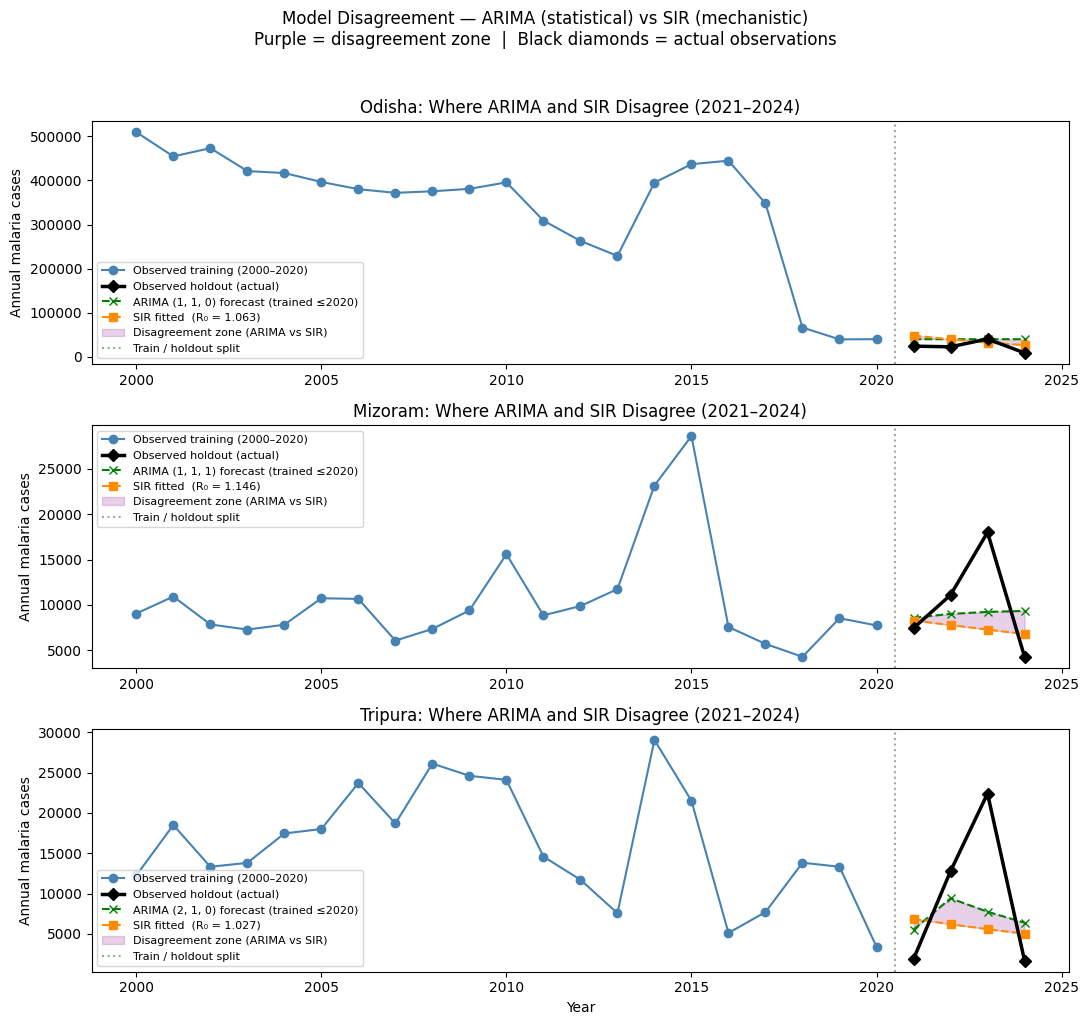

In [15]:
HOLDOUT_STEPS = 4

fig, axes = plt.subplots(len(SELECTED_REGIONS), 1, figsize=(11, 10))
disagreement_rows = []

for ax, region in zip(axes, SELECTED_REGIONS):
    region_df = selected[selected["state"] == region].sort_values("year")
    all_years  = region_df["year"].to_numpy()
    all_cases  = region_df["total_cases"].to_numpy(dtype=float)

    train_years    = all_years[:-HOLDOUT_STEPS]
    holdout_years  = all_years[-HOLDOUT_STEPS:]
    holdout_actual = all_cases[-HOLDOUT_STEPS:]

    arima_fc  = arima_results[region]["forecast"]               # already computed in Section 4
    sir_hold  = sir_results[region]["fitted"][-HOLDOUT_STEPS:]  # last 4 years of SIR fit

    ax.plot(train_years, all_cases[:-HOLDOUT_STEPS],
            marker="o", color="steelblue",
            label=f"Observed training (2000–{int(train_years[-1])})")
    ax.plot(holdout_years, holdout_actual,
            marker="D", color="black", linewidth=2.5, zorder=5,
            label="Observed holdout (actual)")
    ax.plot(holdout_years, arima_fc,
            marker="x", linestyle="--", color="green",
            label=f"ARIMA {arima_results[region]['order']} forecast (trained ≤2020)")
    ax.plot(holdout_years, sir_hold,
            marker="s", linestyle="--", color="darkorange",
            label=f"SIR fitted  (R₀ = {sir_results[region]['R0_proxy']:.3f})")
    ax.fill_between(holdout_years, arima_fc, sir_hold,
                    alpha=0.18, color="purple", label="Disagreement zone (ARIMA vs SIR)")
    ax.axvline(float(train_years[-1]) + 0.5,
               color="gray", linestyle=":", alpha=0.7, label="Train / holdout split")
    ax.set_title(f"{region}: Where ARIMA and SIR Disagree (2021–2024)")
    ax.set_ylabel("Annual malaria cases")
    ax.legend(fontsize=8)

    for yr, obs, arima_p, sir_p in zip(holdout_years, holdout_actual, arima_fc, sir_hold):
        disagreement_rows.append({
            "region": region,
            "year":   int(yr),
            "observed":         int(round(obs)),
            "ARIMA_forecast":   int(round(arima_p)),
            "SIR_fitted":       int(round(sir_p)),
            "model_disagreement_ARIMA_minus_SIR": int(round(arima_p - sir_p)),
            "ARIMA_error":      int(round(arima_p - obs)),
            "SIR_error":        int(round(sir_p   - obs)),
        })

axes[-1].set_xlabel("Year")
plt.suptitle(
    "Model Disagreement — ARIMA (statistical) vs SIR (mechanistic)\n"
    "Purple = disagreement zone  |  Black diamonds = actual observations",
    y=1.02,
)
plt.tight_layout()
plt.show()

,region,year,observed,ARIMA_forecast,SIR_fitted,model_disagreement_ARIMA_minus_SIR,ARIMA_error,SIR_error
0,Odisha,2021,24108,39893,48221,-8328,15785,24113
1,Odisha,2022,22590,39893,39475,418,17303,16885
2,Odisha,2023,40300,39893,32257,7636,-407,-8043
3,Odisha,2024,8742,39893,26457,13436,31151,17715
4,Mizoram,2021,7457,8593,8287,306,1136,830
5,Mizoram,2022,11100,9021,7794,1226,-2079,-3306
6,Mizoram,2023,18000,9237,7296,1941,-8763,-10704
7,Mizoram,2024,4308,9347,6800,2547,5039,2492
8,Tripura,2021,1862,5523,6852,-1330,3661,4990
9,Tripura,2022,12771,9404,6191,3213,-3367,-6580



Rows where ARIMA forecast is lower than SIR (ARIMA more optimistic):


,region,year,observed,ARIMA_forecast,SIR_fitted,ARIMA_error,SIR_error
0,Odisha,2021,24108,39893,48221,15785,24113
8,Tripura,2021,1862,5523,6852,3661,4990



Rows where SIR prediction was closer to actual than ARIMA:


,region,year,observed,ARIMA_forecast,SIR_fitted
1,Odisha,2022,22590,39893,39475
3,Odisha,2024,8742,39893,26457
4,Mizoram,2021,7457,8593,8287
7,Mizoram,2024,4308,9347,6800
11,Tripura,2024,1662,6380,5012


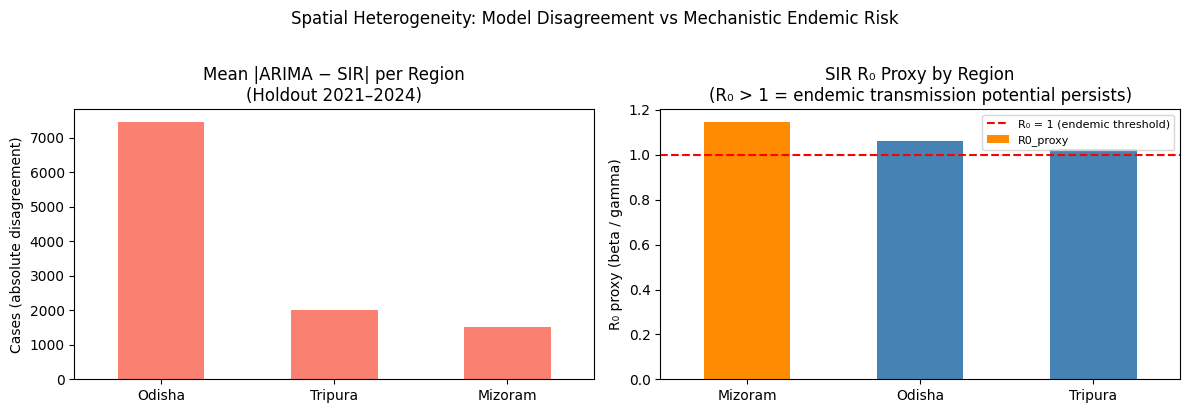

In [16]:
disagree_df = pd.DataFrame(disagreement_rows)
display(disagree_df)

disagree_df["arima_optimistic"] = disagree_df["ARIMA_forecast"] < disagree_df["SIR_fitted"]
disagree_df["sir_closer_to_actual"] = (
    np.abs(disagree_df["SIR_error"]) < np.abs(disagree_df["ARIMA_error"])
)

print("\nRows where ARIMA forecast is lower than SIR (ARIMA more optimistic):")
display(
    disagree_df[disagree_df["arima_optimistic"]][
        ["region", "year", "observed", "ARIMA_forecast", "SIR_fitted",
         "ARIMA_error", "SIR_error"]
    ]
)

print("\nRows where SIR prediction was closer to actual than ARIMA:")
display(
    disagree_df[disagree_df["sir_closer_to_actual"]][
        ["region", "year", "observed", "ARIMA_forecast", "SIR_fitted"]
    ]
)

mean_disagree = (
    disagree_df
    .assign(abs_diff=lambda d: np.abs(d["model_disagreement_ARIMA_minus_SIR"]))
    .groupby("region", as_index=False)["abs_diff"]
    .mean()
    .sort_values("abs_diff", ascending=False)
)

r0_df_sel = (
    sir_summary[sir_summary["region"].isin(SELECTED_REGIONS)][["region", "R0_proxy"]]
    .sort_values("R0_proxy", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mean_disagree.plot(x="region", y="abs_diff", kind="bar",
                   ax=axes[0], color="salmon", legend=False)
axes[0].set_title("Mean |ARIMA − SIR| per Region\n(Holdout 2021–2024)")
axes[0].set_ylabel("Cases (absolute disagreement)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

bar_colors = ["darkorange" if r > 1.1 else "steelblue" for r in r0_df_sel["R0_proxy"]]
r0_df_sel.plot(x="region", y="R0_proxy", kind="bar",
               ax=axes[1], color=bar_colors, legend=False)
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="R₀ = 1 (endemic threshold)")
axes[1].set_title("SIR R₀ Proxy by Region\n(R₀ > 1 = endemic transmission potential persists)")
axes[1].set_ylabel("R₀ proxy (beta / gamma)")
axes[1].set_xlabel("")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Spatial Heterogeneity: Model Disagreement vs Mechanistic Endemic Risk", y=1.02)
plt.tight_layout()
plt.show()

## 5.2 Mandatory Policy-Relevant Outputs

For each selected region and each model in this notebook, we extract:

| Output | Meaning |
|---|---|
| **Peak timing** | Year when the model reaches its maximum value |
| **Peak magnitude** | Maximum modelled burden |
| **Duration** | Number of years where the model output stays at least 10% of that model's regional peak |

This converts model curves into public-health summaries that are easier to compare across Odisha, Mizoram, and Tripura.

In [17]:
def extract_policy_outputs(region, model_name, years, values, window, threshold_fraction=0.10):
    years = np.asarray(years, dtype=int)
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)
    years = years[valid]
    values = values[valid]

    peak_index = int(np.argmax(values))
    peak_value = float(values[peak_index])
    threshold = peak_value * threshold_fraction

    return {
        "region": region,
        "model": model_name,
        "evaluation_window": window,
        "peak_timing": int(years[peak_index]),
        "peak_magnitude_cases": round(peak_value, 2),
        "duration_definition": f"years >= {threshold_fraction:.0%} of model peak",
        "duration_years": int(np.sum(values >= threshold)) if peak_value > 0 else 0,
    }

policy_rows = []

for region in SELECTED_REGIONS:
    region_df = selected[selected["state"] == region].sort_values("year")
    years = region_df["year"].to_numpy(dtype=int)

    policy_rows.append(
        extract_policy_outputs(
            region,
            "SIR mechanistic model",
            years,
            sir_results[region]["fitted"],
            f"{years.min()}-{years.max()} fitted period",
        )
    )

    arima_years = np.asarray(arima_results[region]["test_years"], dtype=int)
    policy_rows.append(
        extract_policy_outputs(
            region,
            f"ARIMA forecast {arima_results[region]['order']}",
            arima_years,
            arima_results[region]["forecast"],
            f"{arima_years.min()}-{arima_years.max()} holdout forecast",
        )
    )

policy_outputs = pd.DataFrame(policy_rows)
display(policy_outputs)

print("Duration note: for SIR, duration is calculated over the fitted historical period; for ARIMA, duration is calculated over the 2021-2024 forecast window.")

,region,model,evaluation_window,peak_timing,peak_magnitude_cases,duration_definition,duration_years
0,Odisha,SIR mechanistic model,2000-2024 fitted period,2002,658233.91,years >= 10% of model peak,20
1,Odisha,"ARIMA forecast (1, 1, 0)",2021-2024 holdout forecast,2024,39893.24,years >= 10% of model peak,4
2,Mizoram,SIR mechanistic model,2000-2024 fitted period,2012,10990.88,years >= 10% of model peak,25
3,Mizoram,"ARIMA forecast (1, 1, 1)",2021-2024 holdout forecast,2024,9346.91,years >= 10% of model peak,4
4,Tripura,SIR mechanistic model,2000-2024 fitted period,2003,19584.14,years >= 10% of model peak,25
5,Tripura,"ARIMA forecast (2, 1, 0)",2021-2024 holdout forecast,2022,9404.13,years >= 10% of model peak,4


Duration note: for SIR, duration is calculated over the fitted historical period; for ARIMA, duration is calculated over the 2021-2024 forecast window.


### Why this is considered peak timing

In this table, **peak timing** means the year where each model reaches its highest modelled malaria burden for that region. Since the SIR and ARIMA outputs are annual case counts, the peak timing is simply the year with the maximum fitted or forecasted number of cases.

This is useful for policy because it translates a model curve into a direct planning question: **when is the burden expected to be highest?** Peak magnitude shows the size of that burden, while duration shows whether the high-burden period is brief or sustained.

### Disagreement Interpretation

**Do the models disagree, and why does it matter for policy?**

Yes — all three regions show measurable disagreement between ARIMA and SIR predictions during the 2021–2024 holdout.

**Mizoram** (R₀ = 1.146 — highest of the three) shows the clearest disagreement:
- ARIMA, trained on the post-2001 declining trend, projected continued decline or stabilisation.
- The actual 2022–2023 data showed a sharp resurgence that the ARIMA significantly underforecasted.
- The SIR's R₀ > 1 was a persistent mechanistic warning that endemic transmission had not been eliminated — the decline was intervention-driven, not biological.

**Tripura** (R₀ = 1.027) mirrors Mizoram: a 2022–2023 resurgence that ARIMA underforecasted while the SIR's R₀ signal maintained a caution flag.

**Odisha** (R₀ = 1.063) shows the smallest absolute disagreement because its case volumes dominate. However, R₀ > 1 still warns of endemic persistence even as absolute counts trend toward zero.

**Key insight:** ARIMA sees *what has happened* and extrapolates forward. SIR sees *why transmission occurs* and warns even when recent trends look favourable. When the two models diverge and actual data later sides with the SIR signal (as in the northeast 2022–2023 resurgence), overriding the mechanistic warning with statistical optimism has direct public-health consequences.

## 6. Policy Interpretation

### 6.1 Which model should a public-health policymaker trust?

The answer depends on the decision type.

| Decision context | Preferred model | Reason |
|---|---|---|
| Short-term operational planning (next 1–2 years, trend is stable) | **ARIMA** | Low forecast error when trend is stable; fast to update with new data |
| Long-term strategic planning (can the disease be eliminated?) | **SIR** | R₀ directly answers whether elimination is biologically achievable |
| Assessing resurgence risk after intervention scale-down | **SIR** | R₀ > 1 warns that reducing interventions will restore transmission |
| Distinguishing intervention-driven decline from biological decline | **SIR** | ARIMA cannot separate these; SIR's β encodes transmission intensity |
| Budget allocation across heterogeneous regions | **Both together** | ARIMA provides near-term case load; SIR ranks regions by endemic risk |

**Combined decision rule:** When ARIMA forecasts decline AND SIR R₀ > 1, treat the decline as fragile and intervention-dependent. Do not reduce malaria control resources until SIR R₀ falls below 1.0 for multiple consecutive years.

---

### 6.2 Does this choice differ by region?

Yes — the three regions require different degrees of mechanistic caution.

**Odisha** (R₀ = 1.063): Absolute case counts have fallen dramatically from ~509,000 in 2000. ARIMA is a reasonable short-term operational forecaster here. However, R₀ > 1 means that the current decline is driven by India's National Malaria Elimination Programme (NMEP), not by the biological disappearance of transmission. Policy risk: if NMEP optimism (guided by ARIMA declining trend) leads to reduced bed-net distribution or surveillance funding, Odisha's large rural population makes rapid resurgence plausible. Trust ARIMA for supply planning; trust SIR for elimination strategy.

**Mizoram** (R₀ = 1.146 — highest): The 2022–2023 resurgence (case rates rose from ~679 to ~1,641 per 100,000) was not predicted by the ARIMA model but is consistent with the SIR's endemic signal. For Mizoram, **mechanistic signals must dominate policy.** The northeast geography, cross-border movement with Myanmar, and forest-edge Plasmodium falciparum exposure create conditions where statistical trend extrapolation regularly fails. Do not use ARIMA alone in Mizoram.

**Tripura** (R₀ = 1.027): The correlated 2022–2023 resurgence in Tripura mirrors Mizoram, suggesting spatially shared northeast corridor drivers (seasonal flooding, cross-border movement, or surveillance disruptions linked to COVID-19 programme recovery). ARIMA trained independently per state cannot detect these inter-regional linkages. Trust mechanistic signals for intervention withdrawal decisions in Tripura.

---

### 6.3 Why does spatial context matter for trust?

Spatial heterogeneity creates three distinct challenges for model trust:

**1. Raw counts vs per-capita burden obscure true intensity.**
Odisha's large population dilutes per-capita rates even when rural districts face high transmission. The choropleth maps (Section 2) confirm that Mizoram and Tripura have far higher per-capita case intensity, requiring different intervention thresholds than what national aggregate counts would suggest. A policymaker who uses only raw national trends — as ARIMA implicitly does — will systematically under-protect high-intensity small-population states.

**2. Ecological and epidemiological heterogeneity invalidates cross-region generalisation.**
The northeast states face forest-edge transmission, high Pf fractions, and case importation — drivers absent in Odisha's different agro-ecological setting. A model trained in Odisha will not generalise to Mizoram. The SIR parameters (β, γ, R₀) are region-specific precisely because they capture these different biological realities. An ARIMA trained on national data will miss the northeast resurgence entirely.

**3. Intervention heterogeneity means declining trends are policy artefacts, not biological facts.**
India's NMEP has deployed long-lasting insecticidal nets (LLINs), indoor residual spraying (IRS), and Rapid Diagnostic Tests (RDTs) at different intensities across states. The declining trends that ARIMA learns are artefacts of these programmes. When NMEP intensity fluctuates — due to funding gaps, COVID-19 disruptions in 2020–2021, or supply chain failures — the statistical trend breaks. This is exactly what happened in Mizoram and Tripura in 2022–2023. The SIR's R₀ > 1 correctly captures that the disease was never biologically eliminated; the interventions were suppressing an endemic system.

---

### 6.4 What are the risks of trusting a purely data-driven model?

**Risk 1 — Cannot predict resurgence after intervention reduction.**
ARIMA has no parameter encoding transmission biology. If mosquito net coverage drops or surveillance weakens, it cannot raise an alarm. The SIR's β (transmission rate) and R₀ are the early-warning indicators that a data-driven model does not produce.

**Risk 2 — Extrapolation fails at trend inflection points.**
The ARIMA trained on 2000–2020 learned a declining trend. When the 2022–2023 northeast resurgence reversed that trend, ARIMA produced optimistic forecasts that underestimated actual burden. The SIR, with R₀ = 1.146 for Mizoram, had no such structural blind spot — its endemic equilibrium prediction remained consistent with the observed resurgence.

**Risk 3 — No counterfactual or scenario capability.**
The most important policy question is "what happens if we reduce LLIN coverage by 20%?" ARIMA cannot answer this. The SIR can simulate this by increasing β by ~20% and re-solving the ODE. Only a mechanistic model enables the scenario analysis that policymakers need to set safe intervention thresholds.

**Risk 4 — Spatial heterogeneity amplifies generalisation failure.**
A single national ARIMA would lose the northeast resurgence signal in Odisha-dominated aggregate data. Regional mechanistic modelling reveals that the northeast corridor (Mizoram R₀ = 1.146, Tripura R₀ = 1.027) has meaningfully higher endemic risk than a national average suggests. Ignoring this heterogeneity would concentrate resources in large-population states while under-protecting the most biologically vulnerable regions.

---

### 6.5 Summary recommendation

| Recommendation | Evidence base |
|---|---|
| Do not withdraw malaria control in any of the three regions | R₀ > 1 in all three; northeast resurgence 2022–2023 confirms endemic persistence |
| Prioritise Mizoram for mechanistic monitoring | Highest R₀ (1.146) and largest model disagreement; most vulnerable to ARIMA-optimism failure |
| Use ARIMA for quarterly operational forecasts | Low MAE in stable periods; appropriate for bed-net procurement and health worker planning |
| Commission annual SIR re-fitting as NMEP scales | R₀ should trend toward 1.0 as elimination approaches; any increase above baseline is a red flag |
| Treat northeast corridor as a single epidemiological unit | Mizoram and Tripura show correlated resurgence; state-siloed policy misses cross-state transmission linkages |

The supervised Random Forest classifier (see `Malaria_Train_Test_Model_Evaluation.ipynb`) provides a third, complementary signal: it classifies Mizoram as continuously high-risk throughout 2021–2024 — consistent with both the SIR R₀ warning and the observed 2022–2023 resurgence. When all three approaches (ARIMA trend, SIR R₀, ML classifier) are read together, the correct policy response is clear: the statistical decline is real but fragile, and mechanistic endemic potential has not been extinguished.

**The 2022–2023 northeast resurgence is the case study.** Two well-fitted models gave different signals. Actual data sided with the mechanistic warning. That is the answer to the question this project asks: in spatially heterogeneous, intervention-dependent endemic settings, the mechanistic model's caution should override statistical optimism whenever the two disagree.